# ASD Detection from Clinical Screening Data

Dataset: Kaggle autismdiagnosis competition, "Autism Prediction in Adults" by REVA Academy
https://www.kaggle.com/competitions/autismdiagnosis/data



## 1. Setup

In [18]:
!pip install -q ucimlrepo scikit-fuzzy


In [19]:

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.cluster import KMeans
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score, f1_score,
)

try:
    import skfuzzy as fuzz
    HAVE_SKFUZZY = True
except ImportError:
    HAVE_SKFUZZY = False

RANDOM_STATE = 42
AQ_COLUMNS = [f"A{i}_Score" for i in range(1, 11)]
KEEP_OTHER = ["age", "gender", "jaundice", "austim", "result", "relation"]

# handles column name variants across data sources
COLUMN_ALIASES = {
    "jaundice": {"jaundice", "jundice"},
    "austim": {"austim", "family_pdd", "pdd"},
}


## 2. Load the dataset

Upload train.csv from the Kaggle autismdiagnosis competition when prompted.

In [20]:

df = None
try:
    from google.colab import files
    print("Please upload the Kaggle competition's train.csv (or your own CSV in the same format).")
    uploaded = files.upload()
    csv_name = next(iter(uploaded.keys()))
    df = pd.read_csv(csv_name, na_values=["?", ""])
    print("Loaded uploaded file:", df.shape)
except ImportError:
    # Not running in Colab
    CSV_PATH = "train.csv"
    try:
        df = pd.read_csv(CSV_PATH, na_values=["?", ""])
        print("Loaded local file:", df.shape)
    except FileNotFoundError:
        print(f"No file at {CSV_PATH!r}. Falling back to ucimlrepo.")
        from ucimlrepo import fetch_ucirepo
        ds = fetch_ucirepo(id=426)
        df = pd.concat([ds.data.features, ds.data.targets], axis=1)
        print("Loaded via ucimlrepo:", df.shape)

df.head()


Please upload the Kaggle competition's train.csv (or your own CSV in the same format).


Saving train.csv to train (1).csv
Loaded uploaded file: (800, 22)


,ID,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,...,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,0,1,0,1,0,1,0,1,...,f,NaN,no,no,Austria,no,6.351166,18 and more,Self,0
1,2,0,0,0,0,0,0,0,0,0,...,m,NaN,no,no,India,no,2.255185,18 and more,Self,0
2,3,1,1,1,1,1,1,1,1,1,...,m,White-European,no,yes,United States,no,14.851484,18 and more,Self,1
3,4,0,0,0,0,0,0,0,0,0,...,f,NaN,no,no,United States,no,2.276617,18 and more,Self,0
4,5,0,0,0,0,0,0,0,0,0,...,m,NaN,no,no,South Africa,no,-4.777286,18 and more,Self,0


## 3. Preprocess

In [21]:

DROP_RESULT_TO_AVOID_LEAKAGE = True  # result duplicates the AQ item sum
if DROP_RESULT_TO_AVOID_LEAKAGE and "result" in KEEP_OTHER:
    KEEP_OTHER = [c for c in KEEP_OTHER if c != "result"]
print("Attributes that will be used as features:", AQ_COLUMNS + KEEP_OTHER)


Attributes that will be used as features: ['A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score', 'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age', 'gender', 'jaundice', 'austim', 'relation']


In [22]:

def preprocess(df: pd.DataFrame):
    df = df.copy()
    df.columns = [c.strip() for c in df.columns]

    rename_map = {}
    for c in df.columns:
        lc = c.strip().lower()
        for canonical, aliases in COLUMN_ALIASES.items():
            if lc in aliases:
                rename_map[c] = canonical
                break
    df = df.rename(columns=rename_map)

    # resolve the label column across naming conventions
    target_candidates = [
        c for c in df.columns
        if c.strip().lower() in {"class/asd", "class", "asd", "target", "class_asd"}
    ]
    if not target_candidates:
        target_candidates = [c for c in df.columns if "class" in c.strip().lower()]
    if not target_candidates:
        raise KeyError(
            "Could not find the ASD label column automatically. "
            f"Columns found: {list(df.columns)}"
        )
    df = df.rename(columns={target_candidates[0]: "Class_ASD"})

    keep_cols = [c for c in AQ_COLUMNS + KEEP_OTHER if c in df.columns]
    df = df[keep_cols + ["Class_ASD"]].dropna(subset=["Class_ASD"])

    df["age"] = pd.to_numeric(df["age"], errors="coerce")
    df["age"] = df["age"].fillna(df["age"].median())

    for col in ["gender", "jaundice", "austim", "relation"]:
        if col in df.columns:
            df[col] = df[col].fillna("Unknown").astype(str)
            df[col] = LabelEncoder().fit_transform(df[col])

    y = (
        df["Class_ASD"].astype(str).str.strip().str.lower()
        .map({"yes": 1, "no": 0, "1": 1, "0": 0})
    )
    X = df.drop(columns=["Class_ASD"])

    # polar encoding of AQ items for the MLR step
    X_polar = X.copy()
    for c in AQ_COLUMNS:
        if c in X_polar.columns:
            X_polar[c] = X_polar[c].map({0: -1, 1: 1}).fillna(X_polar[c])

    mask = y.notna()
    return X[mask], X_polar[mask], y[mask].astype(int)

X, X_polar, y = preprocess(df)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
Xp_train = X_polar.loc[X_train.index]
Xp_test = X_polar.loc[X_test.index]
y_train_arr, y_test_arr = y_train.values, y_test.values

print("Train/test sizes:", X_train.shape, X_test.shape)
print("Class balance (train):", y_train.value_counts(normalize=True).round(3).to_dict())


Train/test sizes: (640, 15) (160, 15)
Class balance (train): {0: 0.798, 1: 0.202}


### 3.1 Baseline: AQ-10 threshold rule

Applies the AQ-10 scoring rule directly, without a classifier.

In [23]:

aq_sum_test = X_test[AQ_COLUMNS].sum(axis=1)
baseline_pred = (aq_sum_test >= 6).astype(int).values
baseline_acc = accuracy_score(y_test_arr, baseline_pred) * 100
baseline_prec = precision_score(y_test_arr, baseline_pred, zero_division=0)
baseline_rec = recall_score(y_test_arr, baseline_pred, zero_division=0)
baseline_f1 = f1_score(y_test_arr, baseline_pred, zero_division=0)
print(f"Naive AQ-10 threshold: Accuracy {baseline_acc:.2f}%, "
      f"Precision {baseline_prec:.3f}, Recall {baseline_rec:.3f}, F1 {baseline_f1:.3f}")


Naive AQ-10 threshold: Accuracy 75.00%, Precision 0.441, Recall 0.938, F1 0.600


### 3.2 Demographics-only classifiers

Same six classifiers trained without the AQ-10 items, using only age, gender, jaundice, family history, and relation.

In [24]:

demo_cols = [c for c in KEEP_OTHER if c in X_train.columns]
Xd_train, Xd_test = X_train[demo_cols].values, X_test[demo_cols].values

demo_results = {}
for name, model in {
    "AdaBoost (demo only)": AdaBoostClassifier(n_estimators=150, random_state=RANDOM_STATE),
    "Decision Tree (demo only)": DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE),
    "Random Forest (demo only)": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
    "Naive Bayes (demo only)": GaussianNB(),
    "LDA (demo only)": LinearDiscriminantAnalysis(),
    "KNN (demo only)": KNeighborsClassifier(n_neighbors=7),
}.items():
    model.fit(Xd_train, y_train_arr)
    pred = model.predict(Xd_test)
    acc = accuracy_score(y_test_arr, pred) * 100
    prec = precision_score(y_test_arr, pred, zero_division=0)
    rec = recall_score(y_test_arr, pred, zero_division=0)
    f1 = f1_score(y_test_arr, pred, zero_division=0)
    demo_results[name] = {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1}
    print(f"{name}: Accuracy {acc:.2f}%, Precision {prec:.3f}, Recall {rec:.3f}, F1 {f1:.3f}")

majority_baseline = max(y_train.value_counts(normalize=True)) * 100
print(f"\nMajority class baseline: {majority_baseline:.2f}%")


AdaBoost (demo only): Accuracy 80.62%, Precision 0.526, Recall 0.312, F1 0.392
Decision Tree (demo only): Accuracy 78.75%, Precision 0.455, Recall 0.312, F1 0.370
Random Forest (demo only): Accuracy 75.00%, Precision 0.367, Recall 0.344, F1 0.355
Naive Bayes (demo only): Accuracy 78.12%, Precision 0.455, Recall 0.469, F1 0.462
LDA (demo only): Accuracy 78.75%, Precision 0.469, Recall 0.469, F1 0.469
KNN (demo only): Accuracy 80.62%, Precision 1.000, Recall 0.031, F1 0.061

Majority class baseline: 79.84%


## 4. Exploratory Data Analysis

Box plots, violin plots, a pairwise scatter matrix, and correlation heatmaps

In [25]:

plot_df = X.copy()
plot_df["Class_ASD"] = y.map({0: "no", 1: "yes"})

melt_cols = [c for c in AQ_COLUMNS + KEEP_OTHER if c in plot_df.columns]
key_attrs = [c for c in KEEP_OTHER if c in plot_df.columns]


### 4.1 Box plots (Figures 5.1, 5.2)

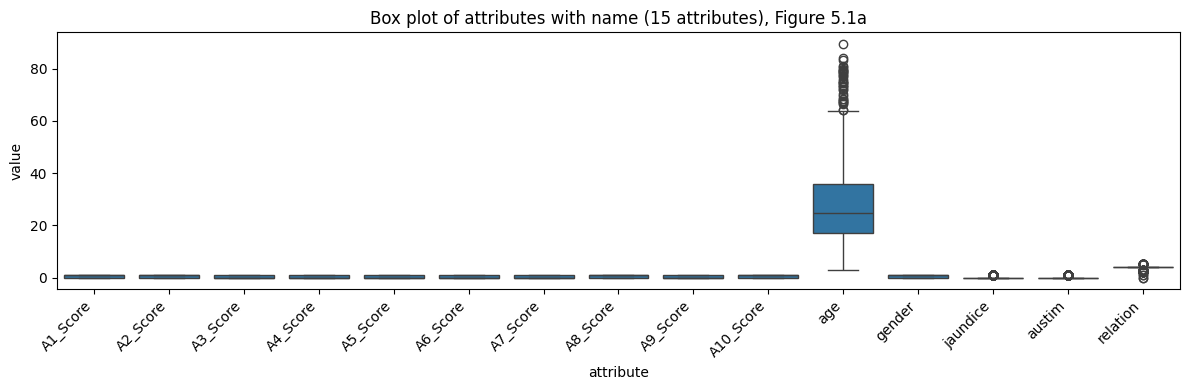

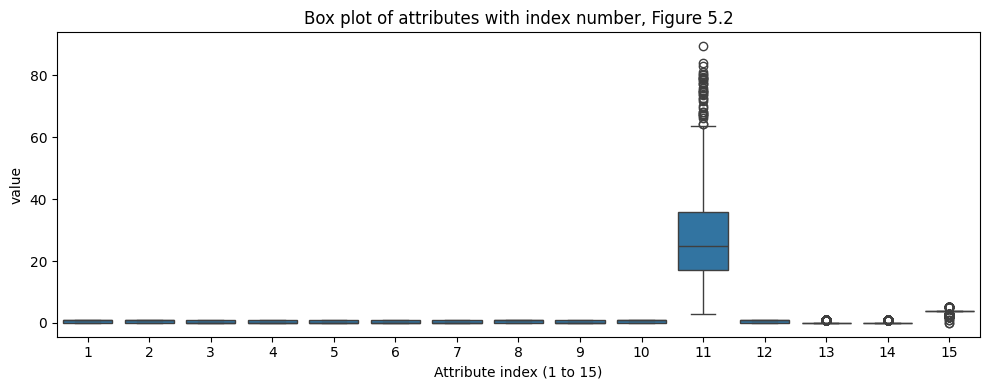

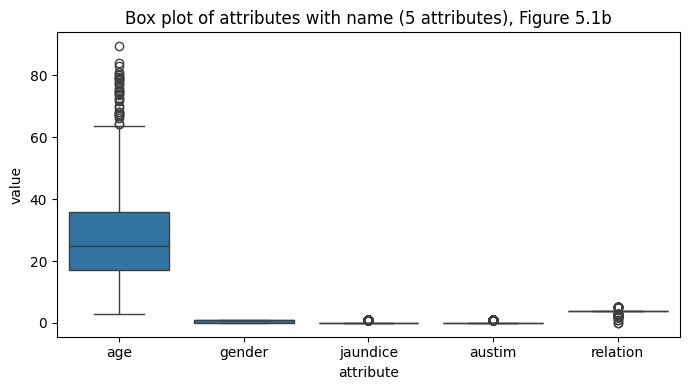

In [26]:

melt_df = plot_df[melt_cols].melt(var_name="attribute", value_name="value")

plt.figure(figsize=(12, 4))
sns.boxplot(data=melt_df, x="attribute", y="value")
plt.xticks(rotation=45, ha="right")
plt.title(f"Box plot of attributes with name ({len(melt_cols)} attributes), Figure 5.1a")
plt.tight_layout(); plt.show()

idx_map = {name: i + 1 for i, name in enumerate(melt_cols)}
melt_df_idx = melt_df.copy()
melt_df_idx["idx"] = melt_df_idx["attribute"].map(idx_map)

plt.figure(figsize=(10, 4))
sns.boxplot(data=melt_df_idx, x="idx", y="value")
plt.xlabel(f"Attribute index (1 to {len(melt_cols)})")
plt.title("Box plot of attributes with index number, Figure 5.2")
plt.tight_layout(); plt.show()

# box plot for the six demographic attributes, Figure 5.1b
plt.figure(figsize=(7, 4))
sns.boxplot(data=plot_df[key_attrs].melt(var_name="attribute", value_name="value"),
            x="attribute", y="value")
plt.title(f"Box plot of attributes with name ({len(key_attrs)} attributes), Figure 5.1b")
plt.tight_layout(); plt.show()


### 4.2 Violin plots by ASD class (Figure 5.3)

Each plot is split by the no and yes ASD outcome.

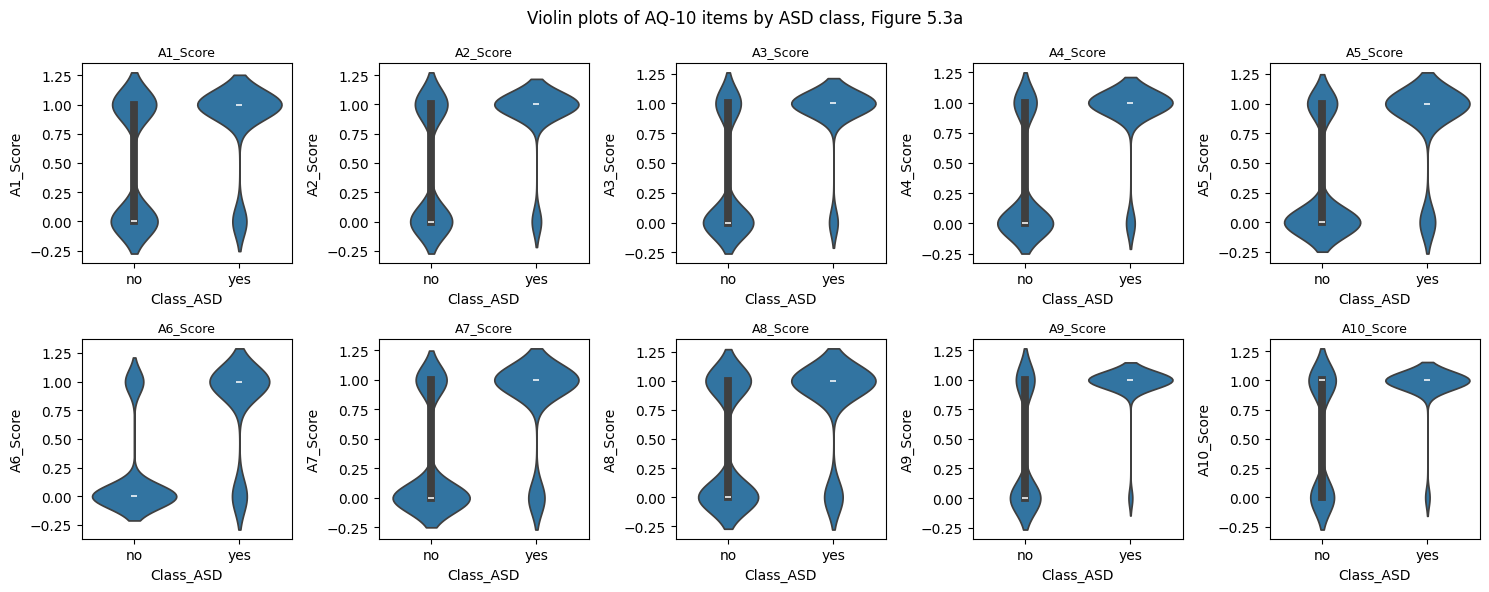

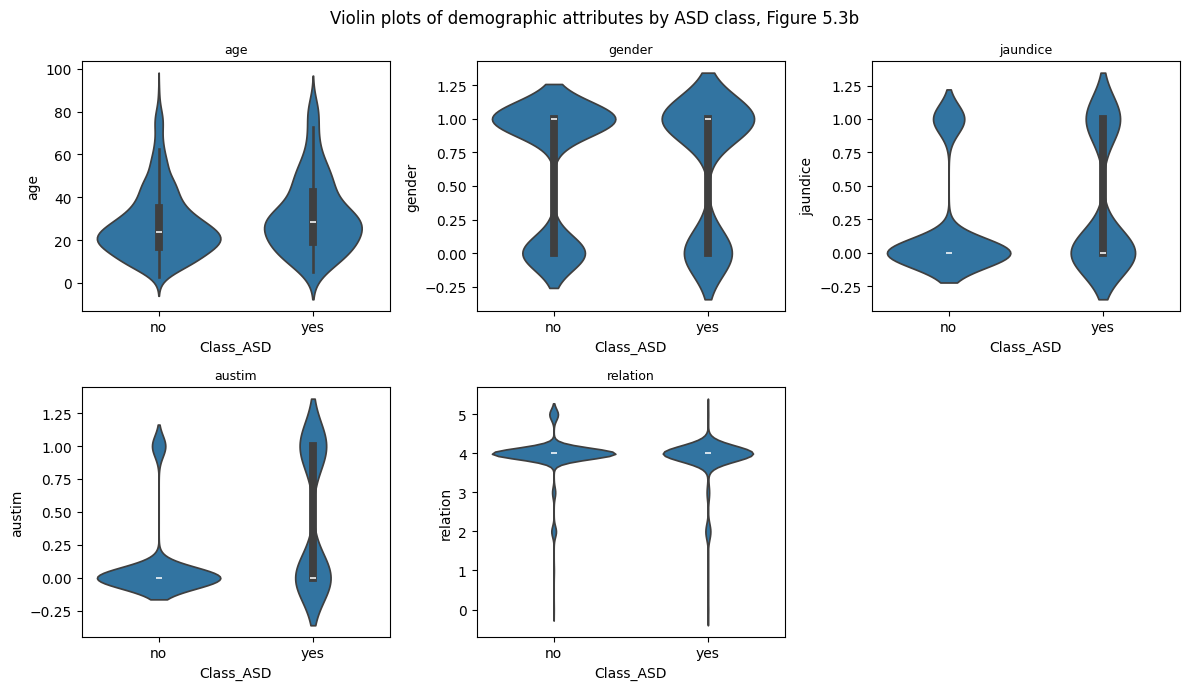

In [27]:

n_aq = len(AQ_COLUMNS)
fig, axes = plt.subplots(2, (n_aq + 1) // 2, figsize=(15, 6))
for ax, col in zip(axes.flat, AQ_COLUMNS):
    sns.violinplot(data=plot_df, x="Class_ASD", y=col, order=["no", "yes"], ax=ax)
    ax.set_title(col, fontsize=9)
for ax in axes.flat[len(AQ_COLUMNS):]:
    ax.axis("off")
fig.suptitle("Violin plots of AQ-10 items by ASD class, Figure 5.3a")
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for ax, col in zip(axes.flat, key_attrs):
    sns.violinplot(data=plot_df, x="Class_ASD", y=col, order=["no", "yes"], ax=ax)
    ax.set_title(col, fontsize=9)
for ax in axes.flat[len(key_attrs):]:
    ax.axis("off")
fig.suptitle("Violin plots of demographic attributes by ASD class, Figure 5.3b")
plt.tight_layout(); plt.show()


### 4.3 Correlation: scatter matrix and heatmap (Figures 5.4, 5.5)

The scatter matrix covers the six demographic attributes. The heatmaps cover all attributes and the six-attribute subset.

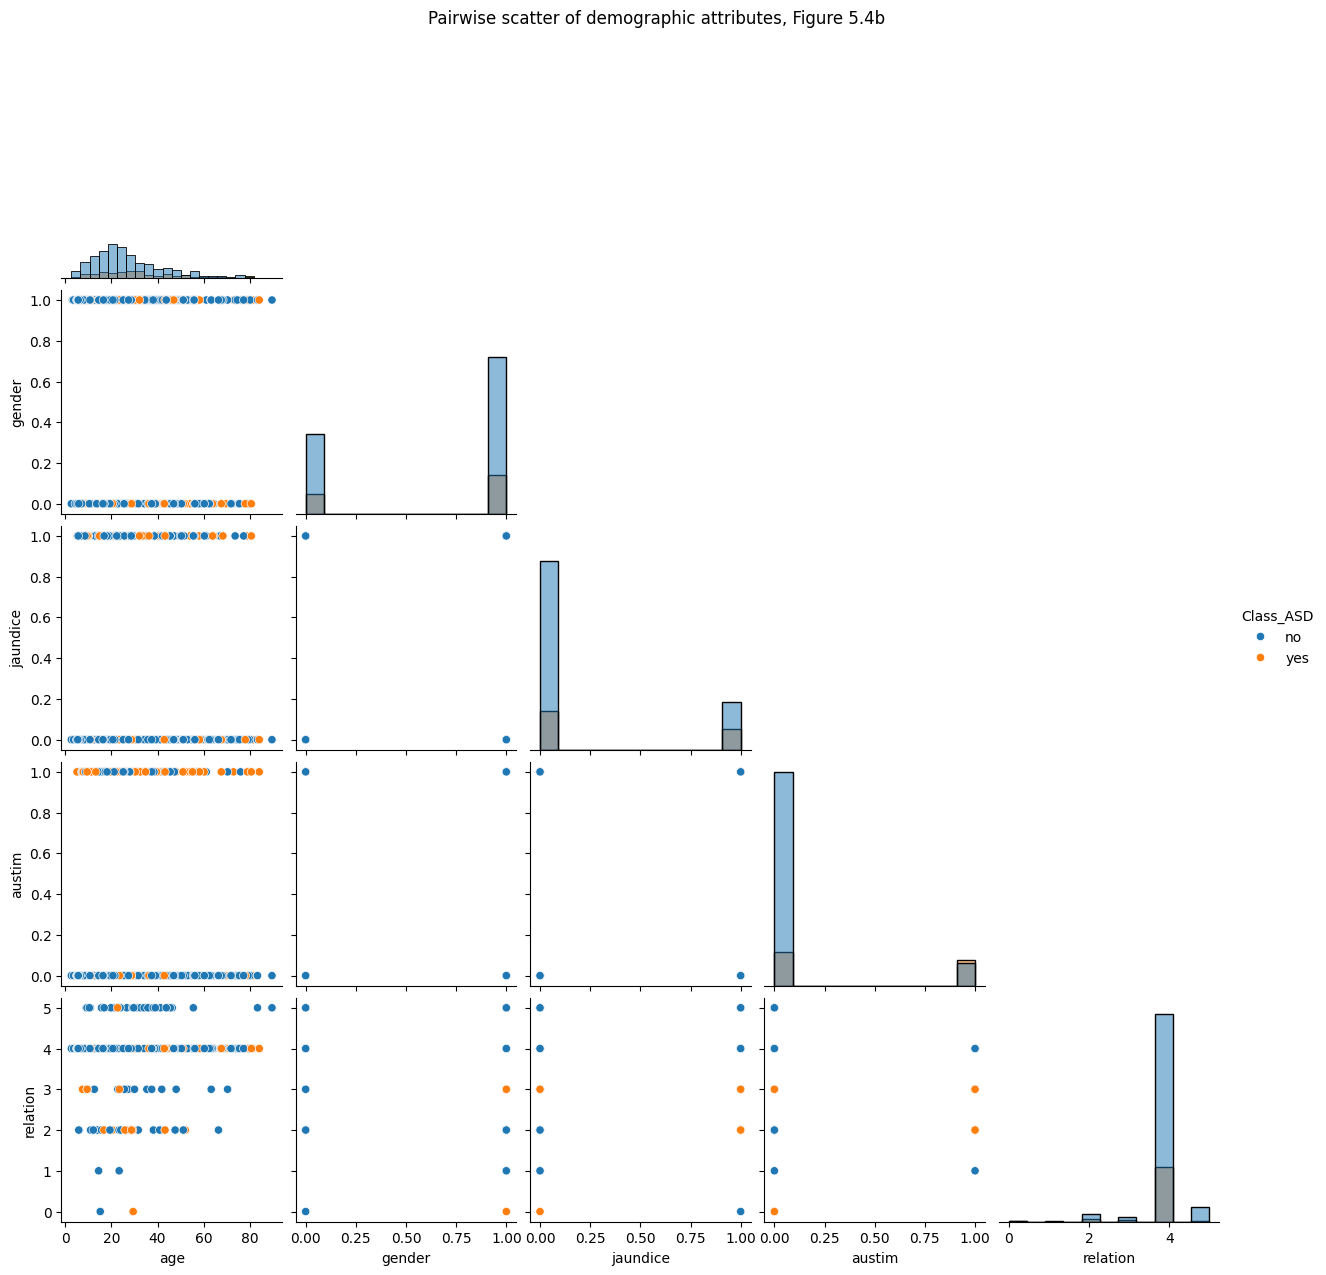

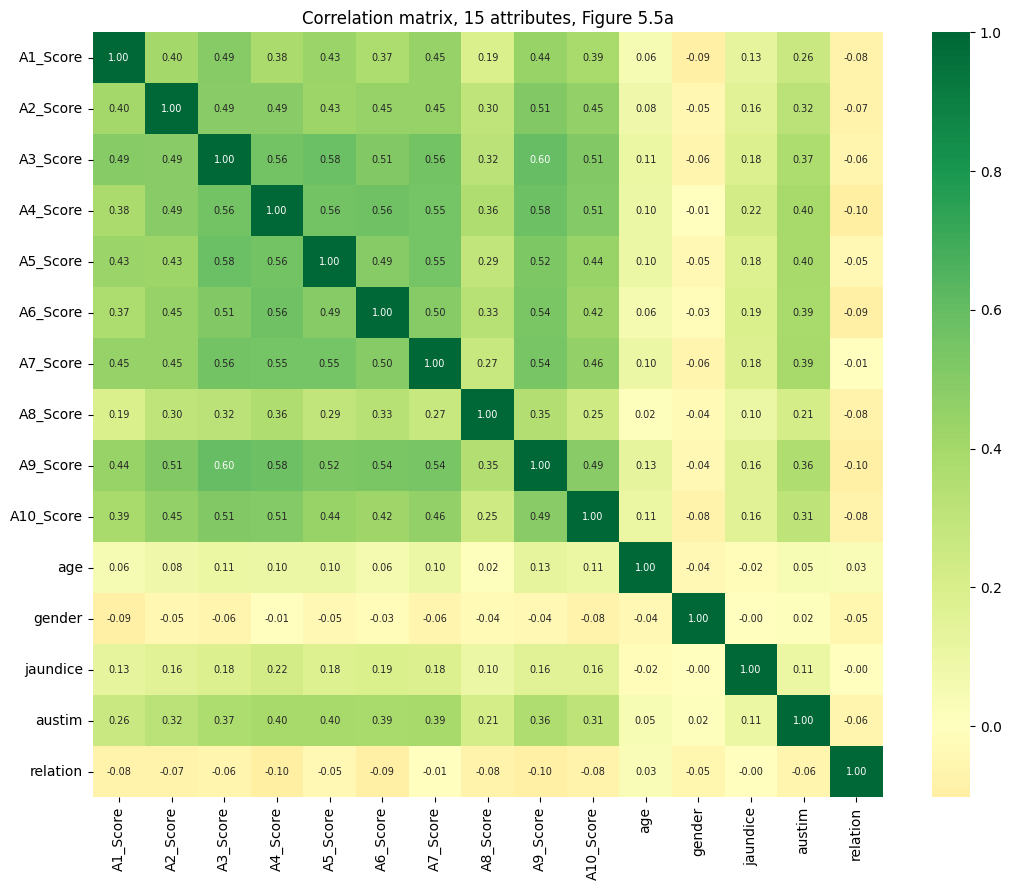

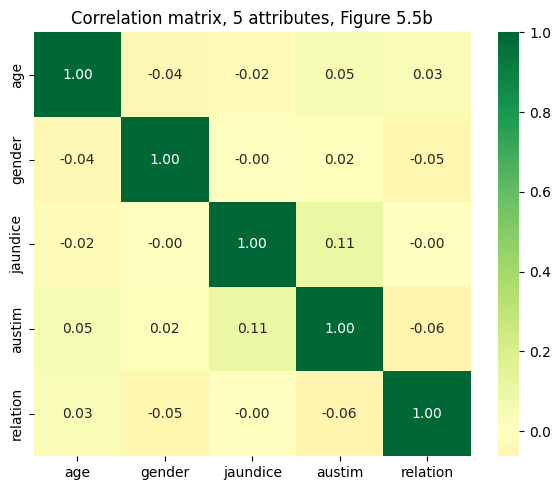

In [28]:

sns.pairplot(plot_df[key_attrs + ["Class_ASD"]], hue="Class_ASD", corner=True, diag_kind="hist")
plt.suptitle("Pairwise scatter of demographic attributes, Figure 5.4b", y=1.02)
plt.show()

plt.figure(figsize=(11, 9))
sns.heatmap(plot_df[melt_cols].corr(), annot=True, fmt=".2f", cmap="RdYlGn", center=0,
            annot_kws={"size": 7})
plt.title(f"Correlation matrix, {len(melt_cols)} attributes, Figure 5.5a")
plt.tight_layout(); plt.show()

plt.figure(figsize=(6, 5))
sns.heatmap(plot_df[key_attrs].corr(), annot=True, fmt=".2f", cmap="RdYlGn", center=0)
plt.title(f"Correlation matrix, {len(key_attrs)} attributes, Figure 5.5b")
plt.tight_layout(); plt.show()


## 5. Evaluation helper

Prints metrics and a confusion matrix heatmap for each model, matching thesis Figures 5.6b, 5.9, 5.12, 5.15.

In [29]:

results = {}
probs = {}

def evaluate(name, y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    acc = accuracy_score(y_true, y_pred) * 100
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    print(f"{name}: Accuracy {acc:.2f}%, Precision {prec:.3f}, Recall {rec:.3f}, F1 {f1:.3f}")

    plt.figure(figsize=(3, 2.6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["no", "yes"], yticklabels=["no", "yes"])
    plt.title(name, fontsize=10)
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

    results[name] = {"accuracy": acc, "precision": prec, "recall": rec, "f1": f1}


## 6. Six base classifiers

AdaBoost, Decision Tree, Random Forest, Naive Bayes, LDA, and KNN, as listed in thesis section 4.2.2.

AdaBoost: Accuracy 85.00%, Precision 0.611, Recall 0.688, F1 0.647


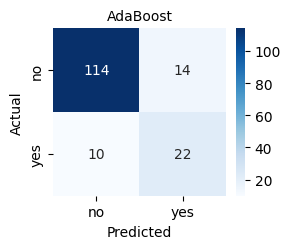

Decision Tree: Accuracy 83.75%, Precision 0.607, Recall 0.531, F1 0.567


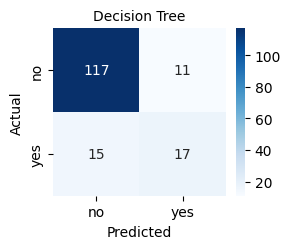

Random Forest: Accuracy 83.75%, Precision 0.600, Recall 0.562, F1 0.581


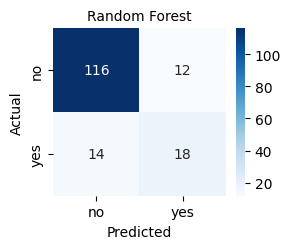

Naive Bayes: Accuracy 79.38%, Precision 0.491, Recall 0.812, F1 0.612


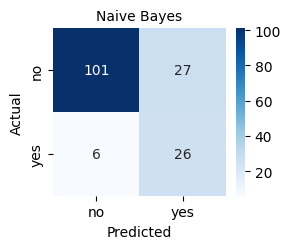

LDA: Accuracy 84.38%, Precision 0.585, Recall 0.750, F1 0.658


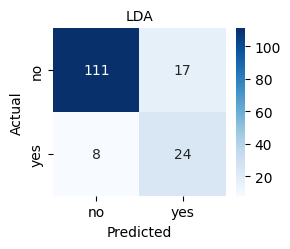

KNN: Accuracy 81.25%, Precision 0.529, Recall 0.562, F1 0.545


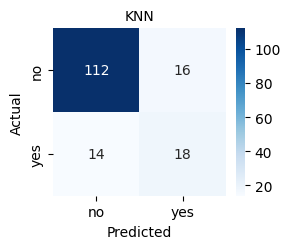

In [13]:

base_models = {
    "AdaBoost": AdaBoostClassifier(n_estimators=150, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
    "Naive Bayes": GaussianNB(),
    "LDA": LinearDiscriminantAnalysis(),
    "KNN": KNeighborsClassifier(n_neighbors=7),
}

for name, model in base_models.items():
    model.fit(X_train.values, y_train_arr)
    pred = model.predict(X_test.values)
    evaluate(name, y_test_arr, pred)
    if hasattr(model, "predict_proba"):
        probs[name] = model.predict_proba(X_test.values)
    else:
        p = pred.astype(float)
        probs[name] = np.vstack([1 - p, p]).T


## 7. Fuzzy C-Means as a soft classifier

Clusters the scaled data into two fuzzy clusters, then labels each cluster by its majority training class, matching thesis section 3.8.

Fuzzy C-Means: Accuracy 80.00%, Precision 0.000, Recall 0.000, F1 0.000


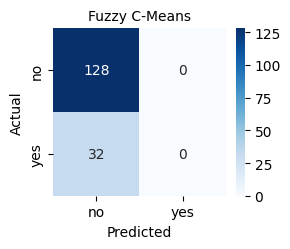

In [14]:

def fcm_classify():
    scaler = StandardScaler().fit(X_train.values)
    Xtr, Xte = scaler.transform(X_train.values), scaler.transform(X_test.values)

    if HAVE_SKFUZZY:
        cntr, u, *_ = fuzz.cluster.cmeans(
            Xtr.T, c=2, m=2, error=0.005, maxiter=1000, seed=RANDOM_STATE
        )
        cluster_labels = np.argmax(u, axis=0)
        cluster_to_class = {
            c: int(round(y_train_arr[cluster_labels == c].mean())) if (cluster_labels == c).any() else 0
            for c in range(2)
        }
        u_test, *_ = fuzz.cluster.cmeans_predict(
            Xte.T, cntr, m=2, error=0.005, maxiter=1000, seed=RANDOM_STATE
        )
        test_cluster = np.argmax(u_test, axis=0)
        pred = np.array([cluster_to_class[c] for c in test_cluster])
        class1_clusters = [c for c, v in cluster_to_class.items() if v == 1]
        p1 = u_test[class1_clusters[0]] if class1_clusters else np.zeros(len(pred))
        prob = np.vstack([1 - p1, p1]).T
    else:
        # k-means fallback when scikit-fuzzy is unavailable
        km = KMeans(n_clusters=2, n_init=10, random_state=RANDOM_STATE).fit(Xtr)
        cluster_to_class = {
            c: int(round(y_train_arr[km.labels_ == c].mean())) if (km.labels_ == c).any() else 0
            for c in range(2)
        }
        test_cluster = km.predict(Xte)
        pred = np.array([cluster_to_class[c] for c in test_cluster])
        prob = np.vstack([1 - pred, pred]).T.astype(float)

    return pred, prob

pred_fcm, prob_fcm = fcm_classify()
evaluate("Fuzzy C-Means", y_test_arr, pred_fcm)
probs["Fuzzy C-Means"] = prob_fcm


## 8. MLR reduction, Logistic Regression, and SVM

Reduces to two dimensions with MLR, classifies with Logistic Regression, then again with SVM on the same points, matching workflow steps five to seven in the thesis.

MLR + Logistic Regression: Accuracy 85.00%, Precision 0.618, Recall 0.656, F1 0.636


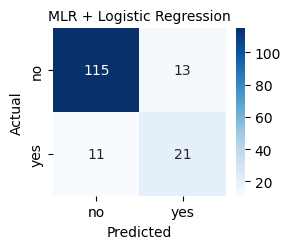

SVM (2D, on MLR output): Accuracy 85.00%, Precision 0.605, Recall 0.719, F1 0.657


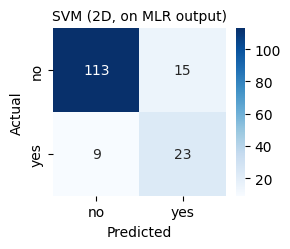

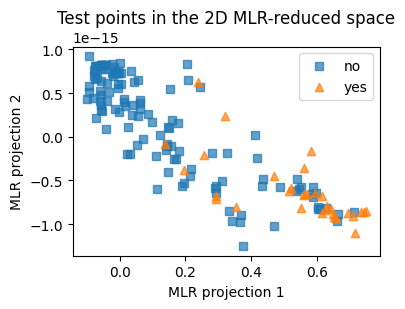

In [15]:

scaler_p = StandardScaler().fit(Xp_train.values)
Xtr_p, Xte_p = scaler_p.transform(Xp_train.values), scaler_p.transform(Xp_test.values)

# two stage linear regression approximating the MLR dimension reduction step
lr1 = LinearRegression().fit(Xtr_p, y_train_arr)
proj1_tr, proj1_te = lr1.predict(Xtr_p), lr1.predict(Xte_p)
resid_tr = y_train_arr - proj1_tr
lr2 = LinearRegression().fit(Xtr_p, resid_tr)
proj2_tr, proj2_te = lr2.predict(Xtr_p), lr2.predict(Xte_p)

Xtr_2d = np.vstack([proj1_tr, proj2_tr]).T
Xte_2d = np.vstack([proj1_te, proj2_te]).T

logreg = LogisticRegression().fit(Xtr_2d, y_train_arr)
pred_lr = logreg.predict(Xte_2d)
evaluate("MLR + Logistic Regression", y_test_arr, pred_lr)
probs["MLR + Logistic Regression"] = logreg.predict_proba(Xte_2d)

svm = SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE).fit(Xtr_2d, y_train_arr)
pred_svm = svm.predict(Xte_2d)
evaluate("SVM (2D, on MLR output)", y_test_arr, pred_svm)
probs["SVM (2D, on MLR output)"] = svm.predict_proba(Xte_2d)

# scatter plot of the 2D points colored by true class, Figures 5.13b and 5.14b
plt.figure(figsize=(4, 3.2))
plt.scatter(Xte_2d[y_test_arr == 0, 0], Xte_2d[y_test_arr == 0, 1], marker="s", label="no", alpha=0.7)
plt.scatter(Xte_2d[y_test_arr == 1, 0], Xte_2d[y_test_arr == 1, 1], marker="^", label="yes", alpha=0.7)
plt.xlabel("MLR projection 1"); plt.ylabel("MLR projection 2")
plt.title("Test points in the 2D MLR-reduced space")
plt.legend(); plt.tight_layout(); plt.show()


## 9. Entropy-weighted fusion

Combines all model outputs, weighting each by one minus its prediction entropy, matching the thesis combining scheme.

Entropy-weighted Fusion (all models): Accuracy 84.38%, Precision 0.613, Recall 0.594, F1 0.603


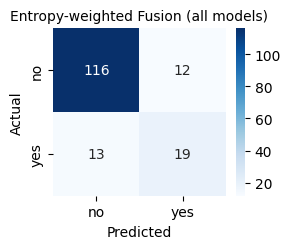

In [16]:

def entropy_fusion():
    eps = 1e-12
    n = len(y_test_arr)
    weighted_votes = np.zeros(n)
    weight_sum = np.zeros(n)
    for name, p_arr in probs.items():
        p = np.clip(p_arr[:, 1], eps, 1 - eps)
        entropy = -(p * np.log2(p) + (1 - p) * np.log2(1 - p))  # 0 (confident) .. 1 (unsure)
        weight = 1 - entropy
        weighted_votes += weight * p
        weight_sum += weight
    fused_prob = weighted_votes / np.clip(weight_sum, eps, None)
    return (fused_prob >= 0.5).astype(int)

pred_fused = entropy_fusion()
evaluate("Entropy-weighted Fusion (all models)", y_test_arr, pred_fused)


## 10. Summary

Same layout as thesis Table 5.1.

,accuracy,precision,recall,f1
AdaBoost,85.000,0.611,0.688,0.647
"SVM (2D, on MLR output)",85.000,0.605,0.719,0.657
MLR + Logistic Regression,85.000,0.618,0.656,0.636
LDA,84.375,0.585,0.750,0.658
Entropy-weighted Fusion (all models),84.375,0.613,0.594,0.603
Decision Tree,83.750,0.607,0.531,0.567
Random Forest,83.750,0.600,0.562,0.581
KNN,81.250,0.529,0.562,0.545
Fuzzy C-Means,80.000,0.000,0.000,0.000
Naive Bayes,79.375,0.491,0.812,0.612


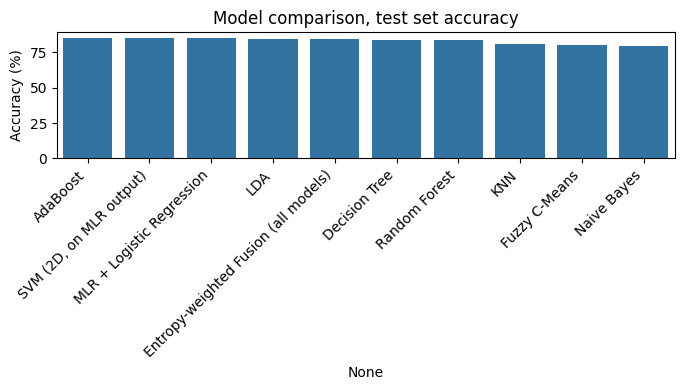

In [17]:

summary = pd.DataFrame(results).T[["accuracy", "precision", "recall", "f1"]].round(3)
summary = summary.sort_values("accuracy", ascending=False)
display(summary)

plt.figure(figsize=(7, 4))
sns.barplot(x=summary.index, y=summary["accuracy"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Accuracy (%)")
plt.title("Model comparison, test set accuracy")
plt.tight_layout()
plt.show()
